# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [ ]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [ ]:









from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(percent10=True, as_frame=True)

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print(df.head())

  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0                        0.11   
1   

In [ ]:
# sample 5000 rows to make training faster

# Sample 5000 rows from the DataFrame, changing random_state for diversity
df = df.sample(n=5000, random_state=1)  # Changed random_state

# Now df_sampled contains your sampled data
df.shape

(5000, 42)

## Data Preprocessing & Feature Engineering

In [ ]:

# Encoding categorical variables into numeric form
encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Convert labels into binary classification (attack or normal)
df['label'] = df['label'].apply(lambda x: 'normal' if x == b'normal.' else 'attack')
df['label'] = encoder.fit_transform(df['label'])

# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
175542,0,0,11,5,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0
399593,0,0,11,5,520,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,520.0,938,0.0
378282,0,1,33,3,0,0,0,0,0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0,0.0,265,0.5
338019,0,0,11,5,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0
174680,0,0,11,5,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0


## Splitting Data into Training and Testing Sets

In [ ]:

X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [ ]:

# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


Random Forest Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       0.99      1.00      1.00       184

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Gradient Boosting Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       0.99      1.00      1.00       184

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

SVM Accuracy: 0.996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       0.99      0.99      0.99       184

    accuracy                           1.00      1000
   macro avg       0.99      0.99      0.99 

## Building a Neural Network Classifier

In [ ]:

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9260 - loss: 0.2690 - val_accuracy: 0.9850 - val_loss: 0.0442
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9815 - loss: 0.0943 - val_accuracy: 0.9940 - val_loss: 0.0188
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9860 - loss: 0.0744 - val_accuracy: 0.9970 - val_loss: 0.0133
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9902 - loss: 0.0445 - val_accuracy: 0.9980 - val_loss: 0.0098
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9915 - loss: 0.0351 - val_accuracy: 0.9980 - val_loss: 0.0094
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9910 - loss: 0.0417 - val_accuracy: 0.9980 - val_loss: 0.0092
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9937 - loss: 0.0230 - val_accuracy: 0.9990 - val_loss: 0.0081
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9955 - loss: 0.0186 - val_accuracy: 0

## Evaluating Neural Network Performance

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Neural Network Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       0.99      1.00      1.00       184

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



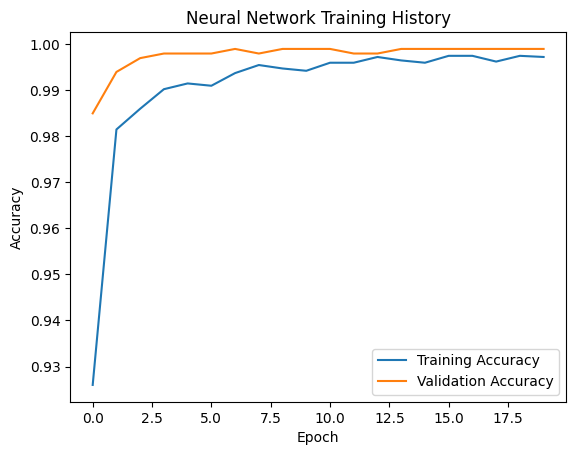

In [ ]:

y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()


Based on the above code, write your own code to develop other ML or Neural network algorithms from list below.

Machine Learning Algorithms
**bold text**
Decision Tree Classifier:  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

K-Nearest Neighbors (KNN):  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Naive Bayes Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


**Deep Learning Models**
Long Short-Term Memory (LSTM): https://keras.io/api/layers/recurrent_layers/lstm/

Convolutional Neural Networks (CNN): https://keras.io/api/layers/convolution_layers/convolution1d/

Transformers (Hugging Face Transformers)

**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import numpy as np

# Dictionary to store results for comparison
results = {}

# --- K-Nearest Neighbors (KNN) ---
knn = KNeighborsClassifier(n_neighbors=5) # Using default n_neighbors=5
kNN.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("\n--- K-Nearest Neighbors Accuracy ---")
print("K-Nearest Neighbors Accuracy:", knn_accuracy)
print(classification_report(y_test, y_pred_knn))
results['KNN'] = {
    'Accuracy': knn_accuracy,
    'Precision': precision_score(y_test, y_pred_knn, average='weighted'),
    'Recall': recall_score(y_test, y_pred_knn, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_knn, average='weighted')
}

# --- Logistic Regression ---
# Max_iter increased to ensure convergence, as default can be too low for scaled data
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
print("\n--- Logistic Regression Accuracy ---")
print("Logistic Regression Accuracy:", log_reg_accuracy)
print(classification_report(y_test, y_pred_log_reg))
results['Logistic Regression'] = {
    'Accuracy': log_reg_accuracy,
    'Precision': precision_score(y_test, y_pred_log_reg, average='weighted'),
    'Recall': recall_score(y_test, y_pred_log_reg, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_log_reg, average='weighted')
}

# --- Long Short-Term Memory (LSTM) ---
# Reshape data for LSTM: (samples, timesteps, features)
# For tabular data, a common approach is to treat each feature vector as a single timestep
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Build the LSTM model
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- Training LSTM Model ---")
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test), verbose=0)

y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype("int32")
lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
print("\n--- LSTM Accuracy ---")
print("LSTM Accuracy:", lstm_accuracy)
print(classification_report(y_test, y_pred_lstm))
results['LSTM'] = {
    'Accuracy': lstm_accuracy,
    'Precision': precision_score(y_test, y_pred_lstm, average='weighted'),
    'Recall': recall_score(y_test, y_pred_lstm, average='weighted'),
    'F1-score': f1_score(y_test, y_pred_lstm, average='weighted')
}

print("\nAll model results compiled:")
for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")


--- K-Nearest Neighbors Accuracy ---
K-Nearest Neighbors Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       0.99      1.00      1.00       184

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Logistic Regression Accuracy ---
Logistic Regression Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       0.99      0.99      0.99       184

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Training LSTM Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

--- LSTM Accuracy ---
LSTM Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       816
           1       0.99      0.99      0.99       184

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


All model results compiled:

KNN:
  Accuracy: 0.9990
  Precision: 0.9990
  Recall: 0.9990
  F1-score: 0.9990

Logistic Regression:
  Accuracy: 0.9980
  Precision: 0.9980
  Recall: 0.9980
  F1-score: 0.9980

LSTM:
  Accuracy: 0.9980
  Precision: 0.9980
  Recall: 0.9980
  F1-score: 0.9980


## Comparing Model Performance with Bar Graphs

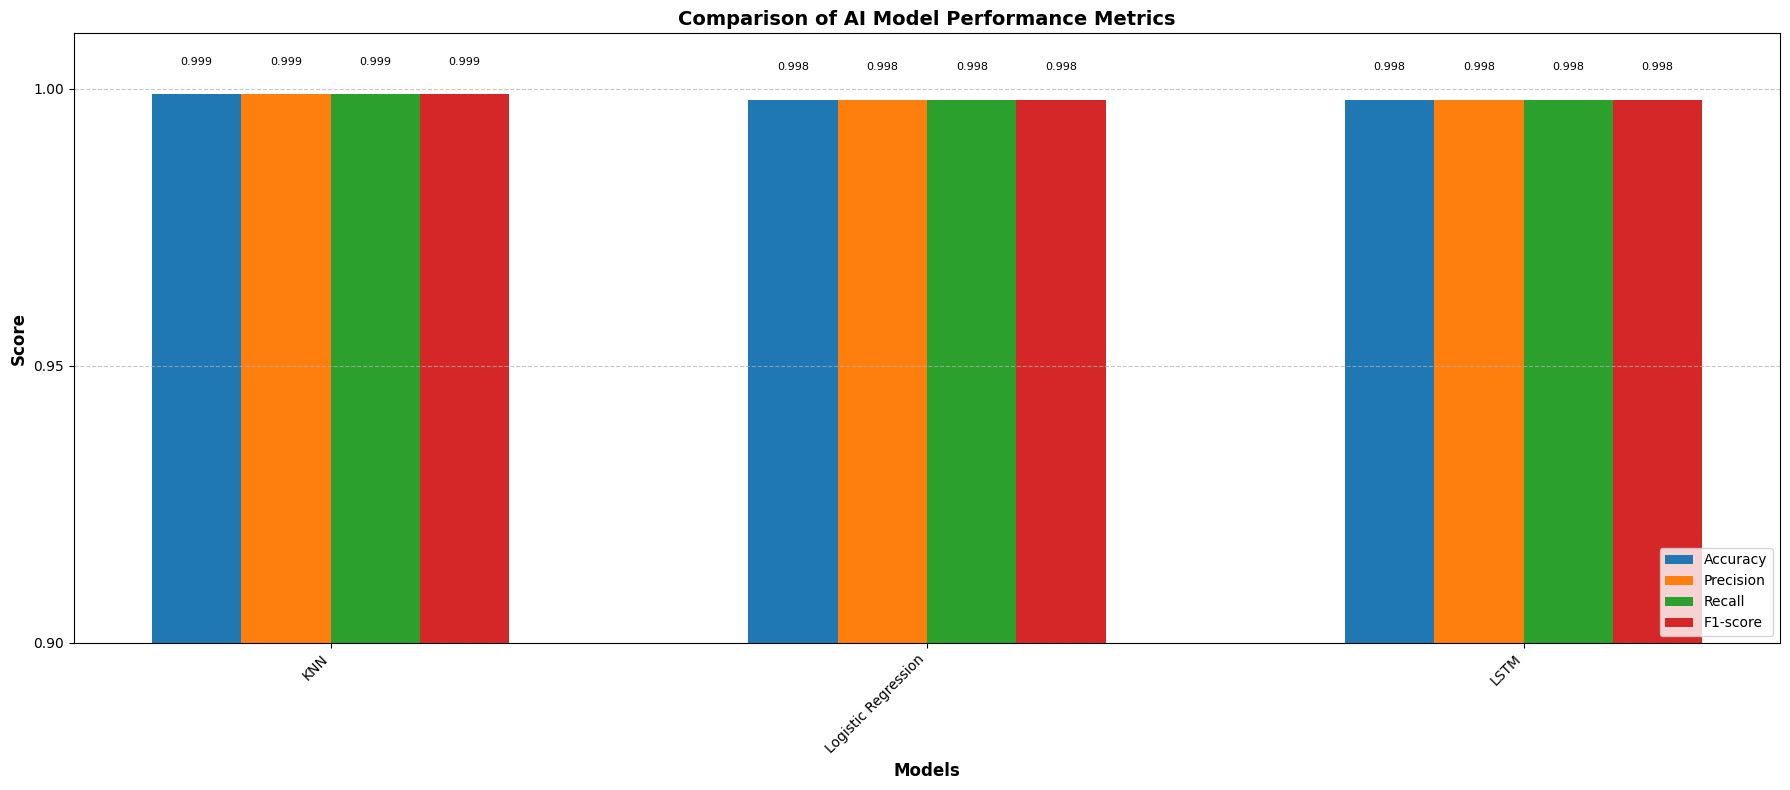

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convert results dictionary to a DataFrame for easier plotting
results_df = pd.DataFrame(results).T

# Define the metrics to plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Set up the bar width and positions for grouped bars
bar_width = 0.15
r_indices = np.arange(len(results_df))

plt.figure(figsize=(18, 8))

# Plot each metric as a separate group of bars
for i, metric in enumerate(metrics):
    bars = plt.bar(r_indices + i * bar_width, results_df[metric], width=bar_width, label=metric)
    # Add value labels on top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3), ha='center', va='bottom', fontsize=8)

plt.xlabel('Models', fontweight='bold', fontsize=12)
plt.ylabel('Score', fontweight='bold', fontsize=12)
plt.title('Comparison of AI Model Performance Metrics', fontweight='bold', fontsize=14)
plt.xticks([r + bar_width * (len(metrics) - 1) / 2 for r in r_indices], results_df.index, rotation=45, ha='right', fontsize=10)
plt.yticks(np.arange(0, 1.05, 0.05))
plt.ylim(0.9, 1.01) # Focus on the higher performance range for better visibility
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()